----
## <font color='CornflowerBlue'>Practical 3: Neural networks with graphs and sequences</font> 
##### Alok Bharadwaj and Arjen Jakobi
---

# 1. Recognizing graphs (~30 min)

Last week you had a short introduction to graphical data type. Here we will recap that with a short exercise. The idea is to get a grasp on recognising nodes and edges in a graph. 

You have to construct a graph based on the following text adapted from "The Murder on the Orient Express" by Agatha Christie 


>> The Orient Express had stalled in the night, snowbound between Belgrade and Brod. In the dining car, the famous Belgian detective Hercule Poirot took his coffee in silence.
Across from him sat M. Bouc, an old friend and director of the Compagnie Internationale des Wagons-Lits. "A curious assortment, mon ami," Bouc remarked. "All nations, all classes — and all snowbound together."
The conductor, Pierre Michel, greeted Mr Poirot and moved between tables with efficiency. "Pierre has been with us fifteen years," Bouc said as he passed. "A good man."
Poirot's gaze travelled the carriage. There was the wealthy American, Mr. Ratchett, with his hard, narrow eyes who had insisted to M. Bouc that he be seated in the carriage next to Mr Poirot. Beside him sat his secretary, Hector MacQueen, employed only six months. Earlier, Poirot had seen MacQueen speaking easily with Colonel Arbuthnot, a retired British Officer.
The Colonel had befriended a Miss Mary Debenham, a young Englishwoman, on the leg from Aleppo. Poirot had overheard them once in a darkened corridor — "Not now," she had said. "When it's all over. When it's behind us."
Further down, Princess Dragomiroff held court with imperial dignity. Her maid, Hildegarde Schmidt, had attended her for thirty years. The Princess nodded to the diplomatic pair across the aisle — Count and Countess Andrenyi of Hungary — old social acquaintances and asked Pierre Michel to bring them some wine. The Countess was a former opera singer, and the Count a diplomat.
After dinner, Ratchett rose and approached Poirot.
"Mr. Poirot. I have enemies, sir. I should like to engage your services."
Poirot regarded him a long moment. "I regret, monsieur, that I do not accept new clients."

Construct a graph based on the text above. The nodes represent the characters in the text and the edges represent whether the characters know each other or not. Interpret the text and construct the graph accordingly. Are there any ambiguous cases? Is some relationship more directed? 

In [23]:
import networkx as nx

G = nx.Graph()

G.add_node(1, name="Hercule Poirot")
G.add_node(2, name="M. Bouc")
# Add more nodes for other characters
G.add_node(3, name="Pierre")
G.add_node(4, name="Ratchett")
G.add_node(5, name="MacQueen")
G.add_node(6, name="Arbuthnot")
G.add_node(7, name="Mary")
G.add_node(8, name="Dragomiroff")
G.add_node(9, name="Hildegarde")
G.add_node(10, name="Count Andrenyi")
G.add_node(11, name="Countess Andrenyi")


In [24]:
# Who knew who in the story
G.add_edge(1, 2)  # Hercule Poirot knew M. Bouc
# Add more edges to represent relationships between characters
G.add_edge(1, 3)  # Hercule Poirot greets Pierre
G.add_edge(2, 3)  # M. Bouc hired Pierre 
G.add_edge(4, 5) # Ratchett hired MacQueen
G.add_edge(5, 6) # MacQueen knew Arbuthnot
G.add_edge(6, 7) # Arbuthnot knew Mary
G.add_edge(8, 9) # Dragomiroff knew Hildegarde
G.add_edge(10, 11) # Count Andrenyi knew Countess Andrenyi
G.add_edge(8, 10) # Dragomiroff knew Count Andrenyi
G.add_edge(8, 11) # Dragomiroff knew Countess Andrenyi
G.add_edge(1, 4) # Hercule Poirot knew Ratchett
#G.add_edge(1, 6) # Poirot overheard Arbuthnot talking to Mary 
#G.add_edge(1, 7) # Poirot overheard Arbuthnot talking to Mary
G.add_edge(3, 8) 
G.add_edge(4, 2) 


See the graph! 

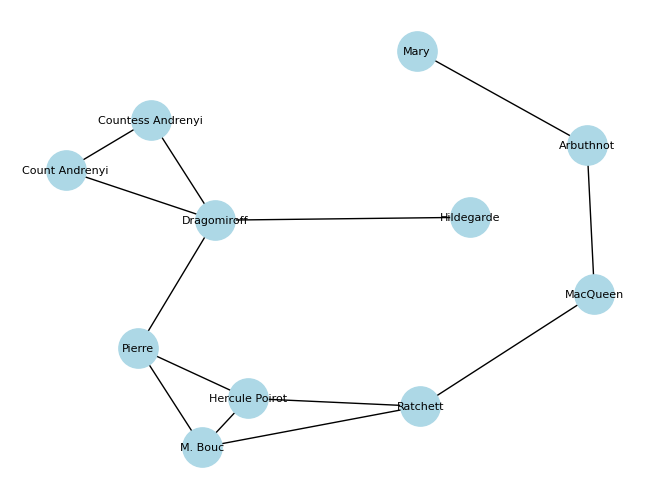

In [43]:
layout = nx.spring_layout(G, seed=1, k=0.75)  # Adjust k for better spacing
node_labels = {node: data['name'] for node, data in G.nodes(data=True)}
nx.draw(G, pos=layout, labels=node_labels, with_labels=True, node_size=800, node_color='lightblue', font_size=8)

# 2. Introduction to protein structures (~30 min)

## How do proteins fold? 

-  Discussion on protein folding and the importance of understanding it. 
-  Show a simple example of a protein sequence and its corresponding 3D structure.

## Representing proteins as graphs

-  Different levels of abstraction for representing proteins as graphs (e.g., residue level, atom level, etc.).

Atomic level
- What do nodes represent? 
- What do edges represent?
- What types of problems can we solve with atomic level protein graphs? 

Residue level
- What do nodes represent?
- What do edges represent?
- What types of problems can we solve with residue level protein graphs?

Domain level
- What do nodes represent?
- What do edges represent?
- What types of problems can we solve with domain level protein graphs?



Answer: 

## 3 Visualization of protein structures and graphs (20 min)

In [44]:
import graphein.protein as gp
from graphein.protein.graphs import construct_graph

params_1 = {
    "granularity": "CA",
    "edge_construction_functions": [
        gp.add_peptide_bonds,
    ],
}

config_1 = gp.ProteinGraphConfig(**params_1)

protein_graph_1 = construct_graph(config=config_1, path='1L2Y.pdb')




Output()

In [45]:
from src.utils import display_protein_with_graph
display_protein_with_graph(protein_graph_1)

Propose a method to construct a feature_vector for each node in the graph. What features would you include? How many dimensions would your feature vector have?

Answer: 

What are the properties of the adjacency matrix for this protein? 

Answer: 

How would the graph change if we added a ligand that binds to the protein?

Answer:

# 4. Graph Convolutional Networks (GCN)


## Understanding Message Passing

### Play a simple game with your neighbor! 

- Each of you has a feature: three numbers which represent the following aspects about you: 
 1) Do you like cats or dogs? (1 for cats, 0 for dogs)
 2) What was the digit that you drew for last week's MNIST assignment? (0-9)
 3) What are the chances that you think it will rain tomorrow? (0-1)
 
Create your feature vector


In [19]:
import numpy as np
your_node_id = 0 # 
your_feature_vector = [1, 4, 0.78]


Update your feature vector in the Google Sheet document next to your node id

Google Sheet link: ____ 


Message passing step:
- You will then collect the feature vectors from all your neighbors (next to you in all directions) and compute a new feature vector for yourself by taking the average of your neighbors' feature vectors.
- You will share your vector with your neighbors

In [21]:
# Uncomment and modify the following lines to define your neighbors and their features
your_neighbors_features = [
    [0, 2, 0.5],  # Neighbor 1
    [1, 3, 0.9],  # Neighbor 2
]

Aggregation step:
- You will then take the average of the feature vectors you received from your neighbors and update your own feature vector with this new information.

In [22]:
neighbors_feature_matrix = np.array(your_neighbors_features)
your_new_feature_vector = np.mean(neighbors_feature_matrix, axis=0)
print("Your original feature vector:", your_feature_vector)
print("Your new feature vector after aggregation:", your_new_feature_vector)


Your original feature vector: [1, 4, 0.78]
Your new feature vector after aggregation: [0.5 2.5 0.7]


Note in this step you did now use any weight while aggregating the information from your neighbors. You also did not normalise the information. This is a simple example of a message passing step in a GCN. In practice, we would use learnable weights and normalisation to improve the performance of the model.

Now, update your new feature vector in the Google Sheet document to see how the information propagates through the network.

That is it! 

# 5. Training GCN 

The actual update rule for a GCN layer is as follows:
\begin{equation}
\mathbf{h}_i^{(l+1)} = \sigma \left( \sum_{j \in \mathcal{N}(i)} \frac{1}{\sqrt{d_i d_j}} \mathbf{W}^{(l)} \mathbf{h}_j^{(l)} \right)
\end{equation}

Where:
- $\mathbf{h}_i^{(l)}$ is the feature vector of node $i$ at layer $l$. Shape = ($d_{in}$, 1)
- $\mathcal{N}(i)$ is the set of neighbors of node $i$
- $d_i$ is the degree of node $i$
- $\mathbf{W}^{(l)}$ is the weight matrix for layer $l$. Shape = ($d_{out}$, $d_{in}$)
- $\sigma$ is the activation function (e.g., ReLU)



Note that the weight matrix $\mathbf{W}^{(l)}$ is learnable. This will be shared across all nodes in the graph, which allows the model to learn a generalizable representation of the graph structure.

### Training a GNN model on the protein graph